# Marginal Uniformization

This notebook demonstrates how to use `MarginalUniformize` and
`MarginalKDEGaussianize` from the new `rbig` API to transform marginal
distributions to a uniform [0, 1] distribution.

The marginal uniformization step is the first building block of the RBIG
algorithm: before applying the probit (inverse Gaussian CDF) transform, we
map each feature to the uniform distribution using an empirical CDF.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

from rbig import MarginalKDEGaussianize, MarginalUniformize

plt.style.use("seaborn-v0_8-paper")

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

We draw samples from a Gamma distribution (a skewed, non-uniform marginal) to
demonstrate the transform.

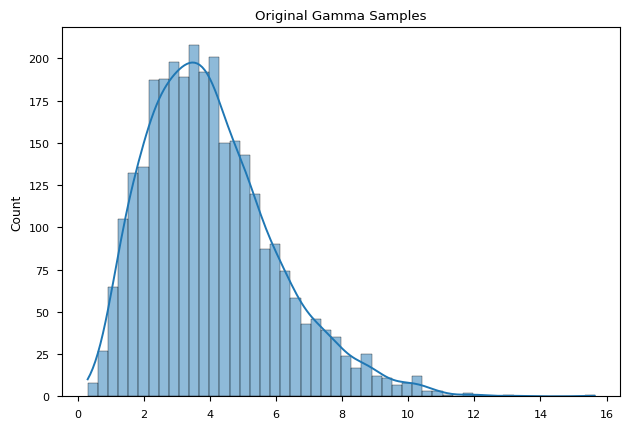

In [2]:
seed = 123
n_samples = 3_000
a = 4  # shape parameter for Gamma

# initialise data distribution
data_dist = stats.gamma(a=a)

# draw samples — shape (n_samples, 1) required by the new API
X = data_dist.rvs(size=(n_samples, 1), random_state=seed)

fig, ax = plt.subplots()
ax.set_title("Original Gamma Samples")
sns.histplot(X[:, 0], ax=ax, bins=50, kde=True)
plt.tight_layout()
plt.show()

## Method I — Empirical CDF (MarginalUniformize)

`MarginalUniformize` uses the empirical CDF (rank-based) to map each marginal
to [0, 1].  It is deterministic and efficient for large datasets.

### Fit the model

In [3]:
marg_unif = MarginalUniformize(bound_correct=True, eps=1e-6)
marg_unif.fit(X)

,bound_correct,True
,eps,1e-06
,pdf_extension,0.0
,pdf_resolution,1000


### Transform: original → uniform

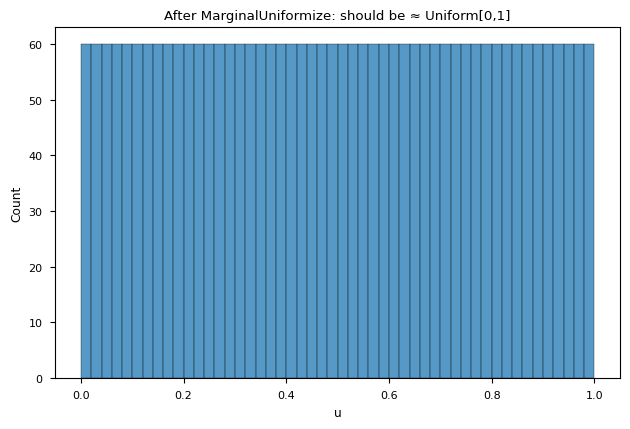

In [4]:
Xu = marg_unif.transform(X)

fig, ax = plt.subplots()
ax.set_title("After MarginalUniformize: should be ≈ Uniform[0,1]")
sns.histplot(Xu[:, 0], ax=ax, bins=50)
ax.set_xlabel("u")
plt.tight_layout()
plt.show()

### Inverse transform: uniform → original

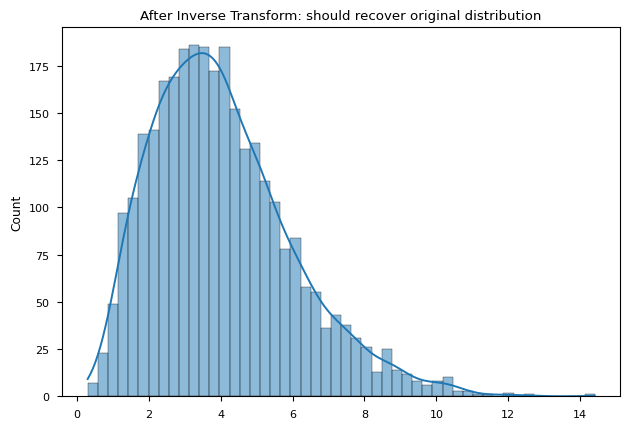

In [5]:
X_approx = marg_unif.inverse_transform(Xu)

fig, ax = plt.subplots()
ax.set_title("After Inverse Transform: should recover original distribution")
sns.histplot(X_approx[:, 0], ax=ax, bins=50, kde=True)
plt.tight_layout()
plt.show()

### Verify round-trip accuracy

In [6]:
residual = np.abs(X - X_approx).mean()
print(f"Mean absolute round-trip error: {residual:.4e}")

Mean absolute round-trip error: 2.0487e-03


## Method II — KDE-based Gaussianization (MarginalKDEGaussianize)

`MarginalKDEGaussianize` estimates the CDF via Kernel Density Estimation (KDE)
and then applies the probit transform Φ⁻¹ to map samples to a standard
Gaussian distribution.  This is smoother than the empirical-CDF approach and
produces a Gaussian (not uniform) output.

### Fit the model

In [7]:
marg_kde = MarginalKDEGaussianize(bw_method="scott", eps=1e-6)
marg_kde.fit(X)

,bw_method,'scott'
,eps,1e-06


### Transform: original → Gaussian

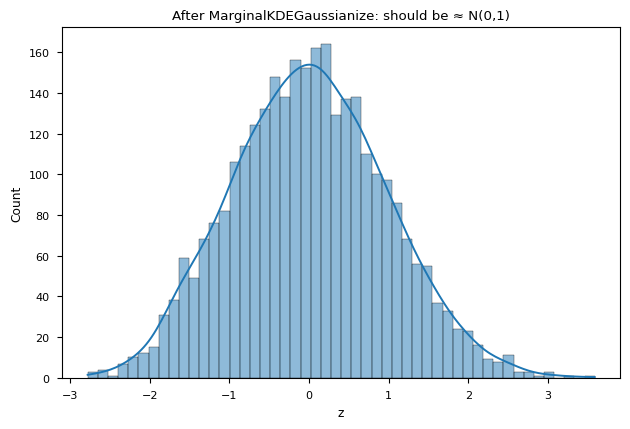

In [8]:
Xg = marg_kde.transform(X)

fig, ax = plt.subplots()
ax.set_title("After MarginalKDEGaussianize: should be ≈ N(0,1)")
sns.histplot(Xg[:, 0], ax=ax, bins=50, kde=True)
ax.set_xlabel("z")
plt.tight_layout()
plt.show()

### Inverse transform: Gaussian → original

> **Note**: The KDE inverse transform uses a numerical root-finding algorithm
> (`scipy.optimize.brentq`) so it is slower than the forward transform,
> especially for large datasets.

In [9]:
# Use a small subset for the inverse to keep runtime reasonable
X_sub = X[:500]
Xg_sub = marg_kde.transform(X_sub)
X_approx_kde = marg_kde.inverse_transform(Xg_sub)

residual_kde = np.abs(X_sub - X_approx_kde).mean()
print(f"Mean absolute KDE round-trip error (n=500): {residual_kde:.4e}")

Mean absolute KDE round-trip error (n=500): 4.4534e-14


### Comparison: empirical vs. KDE density estimate

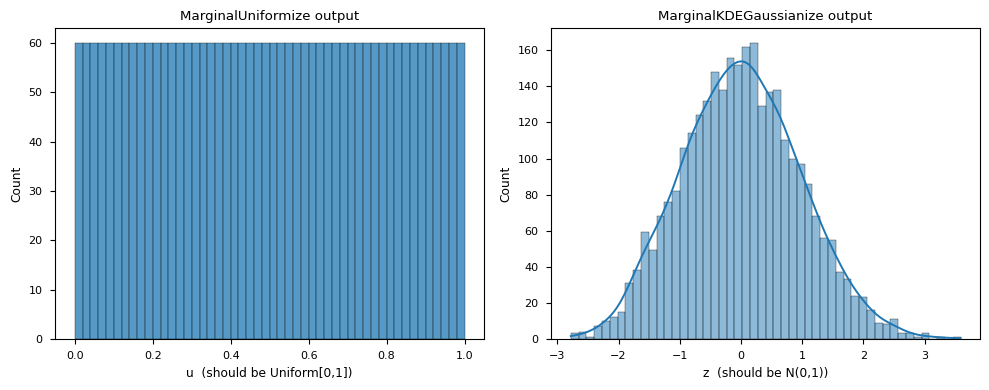

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].set_title("MarginalUniformize output")
sns.histplot(marg_unif.transform(X)[:, 0], ax=axes[0], bins=50)
axes[0].set_xlabel("u  (should be Uniform[0,1])")

axes[1].set_title("MarginalKDEGaussianize output")
sns.histplot(marg_kde.transform(X)[:, 0], ax=axes[1], bins=50, kde=True)
axes[1].set_xlabel("z  (should be N(0,1))")

plt.tight_layout()
plt.show()

## Summary

| Transform | Output distribution | Speed | Use case |
|---|---|---|---|
| `MarginalUniformize` | Uniform [0, 1] | Fast (rank-based) | Pre-processing step in RBIG |
| `MarginalKDEGaussianize` | Standard Gaussian | Slower (KDE + root-find) | Smooth density estimation |

Both transforms implement `.fit()`, `.transform()`, and `.inverse_transform()`
following the scikit-learn estimator API.